<a href="https://colab.research.google.com/github/NazHub1993/ML_Notebooks/blob/main/KNN_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
df=pd.read_csv('iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
df.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [26]:
dummies=pd.get_dummies(df.species).astype(int)
dummies.head()

,setosa,versicolor,virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [27]:
df=pd.concat([df,dummies],axis='columns')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


In [28]:
df=df.drop('species',axis='columns')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [29]:
df[df.setosa==1].head()

,sepal_length,sepal_width,petal_length,petal_width,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [30]:
df[df.versicolor==1].head()


,sepal_length,sepal_width,petal_length,petal_width,setosa,versicolor,virginica
50,7.0,3.2,4.7,1.4,0,1,0
51,6.4,3.2,4.5,1.5,0,1,0
52,6.9,3.1,4.9,1.5,0,1,0
53,5.5,2.3,4.0,1.3,0,1,0
54,6.5,2.8,4.6,1.5,0,1,0


In [31]:
df[df.virginica==1].head()

,sepal_length,sepal_width,petal_length,petal_width,setosa,versicolor,virginica
100,6.3,3.3,6.0,2.5,0,0,1
101,5.8,2.7,5.1,1.9,0,0,1
102,7.1,3.0,5.9,2.1,0,0,1
103,6.3,2.9,5.6,1.8,0,0,1
104,6.5,3.0,5.8,2.2,0,0,1


In [32]:
df1=df[df.setosa==1]
df2=df[df.versicolor==1]
df3=df[df.virginica==1]

In [33]:
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


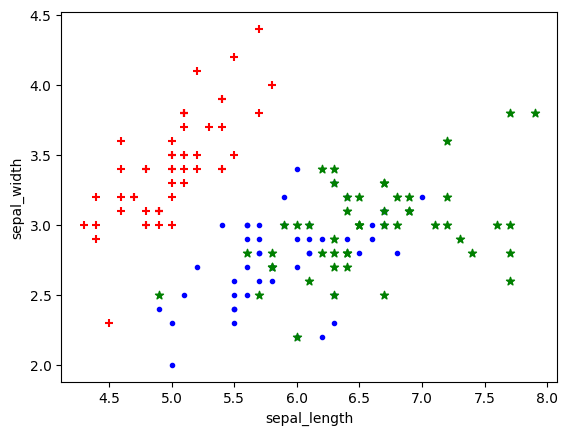

In [34]:
import matplotlib.pyplot as plt
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.scatter(df1.sepal_length,df1.sepal_width,color='red',marker='+')
plt.scatter(df2.sepal_length,df2.sepal_width,color='blue',marker='.')
plt.scatter(df3.sepal_length,df3.sepal_width,color='green',marker='*')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df[['setosa', 'versicolor', 'virginica']].idxmax(axis=1) # Reconstruct the original species labels

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Features scaled successfully!")

Features scaled successfully!


In [37]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
model.score(x_test_scaled,y_test)

1.0

In [40]:
from sklearn.metrics import confusion_matrix
y_pred=model.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


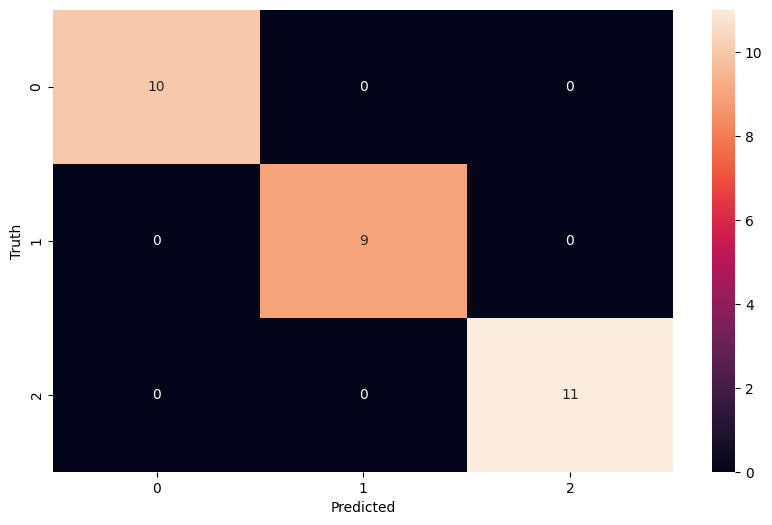

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

